<a href="https://colab.research.google.com/github/devans2718/cs5542-lab03/blob/main/CS5542_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 5542 — Lab 3: Multimodal RAG Systems & Retrieval Evaluation  
**Text + Images/PDFs (runs offline by default; optional LLM API hook)**

This notebook is a **student-ready, simplified, and fully runnable** lab workflow for **multimodal retrieval-augmented generation (RAG)**:
- ingest **PDF text** + **image captions/filenames**
- retrieve evidence with a lightweight baseline (TF‑IDF)
- build a **context block** for answering
- evaluate retrieval quality (Precision@5, Recall@10)
- run an **ablation study** (REQUIRED)

> ✅ **Important:** The code is optimized for **clarity + reproducibility for students** (minimal dependencies, no keys required).  
> It is not the “fastest possible” or “best-performing” RAG system — but it is a correct baseline that you can extend.

---

## Student Tasks (what you must do)
1. **Ingest** PDFs + images from `project_data_mm/` (or use the provided sample package).  
2. Implement / experiment with **chunking strategies** (page-based vs fixed-size).  
3. Compare retrieval methods (at least):  
   - **Sparse** (TF‑IDF / BM25-style)  
   - **Dense** (optional: embeddings)  
   - **Hybrid** (score fusion with `alpha`)  
   - **Hybrid + rerank** (optional: reranker / LLM rerank)  
4. Build a **multimodal context** that includes **evidence items** (text + images).  
5. Produce the required **results table**:

`Query × Method × Precision@5 × Recall@10 × Faithfulness`

---

## Expected Outputs (what graders look for)
- Printed ingestion counts (how many PDF pages/chunks, how many images)
- A retrieval demo showing **top‑k evidence** for a query
- Evaluation metrics per method (P@5, R@10)
- An ablation section with a small comparison table + short explanation


## Key Parameters You Can Tune (and what they do)

These parameters control retrieval + context building. **Students should change them and report what happens.**

- **`TOP_K_TEXT`**: how many text chunks to consider as candidates.  
  - Larger → more recall, but more noise (lower precision).
- **`TOP_K_IMAGES`**: how many image items to consider as candidates.  
  - Larger → more multimodal evidence, but can add irrelevant images.
- **`TOP_K_EVIDENCE`**: how many total evidence items (text+image) go into the final context.  
  - Larger → longer context; may dilute answer quality.
- **`ALPHA`** *(0 → 1)*: **fusion weight** when mixing text vs image evidence.  
  - `ALPHA = 1.0` → text dominates  
  - `ALPHA = 0.0` → images dominate  
  - typical starting point: `0.5`
- **`CHUNK_SIZE`** (fixed-size chunking): characters per chunk (baseline).  
  - Smaller → more granular retrieval (often higher precision)  
  - Larger → fewer chunks (often higher recall but less specific)
- **`CHUNK_OVERLAP`**: overlap between chunks to avoid cutting important info.  
  - Too high → redundant chunks; too low → missing context boundaries

### What to try (recommended student experiments)
- Keep everything fixed, vary **`ALPHA`**: 0.2, 0.5, 0.8  
- Vary **`TOP_K_TEXT`**: 2, 5, 10  
- Compare **page-based** vs **fixed-size** chunking (required ablation)


## 0) Student Info (Fill in)
- Name: Daniel Evans
- UMKC ID: 14283316
- Course/Section: CS-5542


## 1) Setup (student-friendly baseline)

This lab starter is designed to be **easy to run** and **easy to modify**:
- **PyMuPDF (`fitz`)** for PDF text extraction
- **scikit-learn** for TF‑IDF retrieval (strong sparse baseline)
- **Pillow** for basic image IO
- Optional: connect an **LLM API** for answer generation (not required to run retrieval + eval)

### Student guideline
- First make sure **retrieval + metrics** run end-to-end.
- Then iterate: chunking → retrieval method → fusion (`ALPHA`) → rerank → faithfulness.

> If you have API keys (e.g., Gemini / OpenAI / etc.), you can plug them into the optional LLM hook later —  
> but your retrieval evaluation should work **without** any external keys.


In [1]:
# Imports
import os, re, glob, json, math
from dataclasses import dataclass, field
from typing import List, Dict, Any, Tuple, Optional

import numpy as np
import pandas as pd

!pip install -q pymupdf sentence-transformers faiss-cpu

import fitz  # PyMuPDF
from PIL import Image

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

print("✅ All packages imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 23.3 MB/s eta 0:00:00
✅ All packages imported successfully!


In [46]:
# =========================
# Lab Configuration (EDIT ME)
# =========================
# CHANGE FROM ORIGINAL: Using CFR documents instead of sample data

DATA_DIR = "cfr_data"
PDF_DIR  = DATA_DIR  # PDFs are directly in this folder
IMG_DIR  = os.path.join(DATA_DIR, "extracted_images")

# Retrieval knobs
TOP_K_TEXT     = 6    # candidate text chunks
TOP_K_IMAGES   = 3    # candidate images (based on captions/filenames)
TOP_K_EVIDENCE = 7    # final evidence items used in the context

# Fusion knob (text vs images)
ALPHA = 0.6  # 0.0 = images dominate, 1.0 = text dominates

# Chunking knobs (for fixed-size chunking ablation)
CHUNK_SIZE    = 800   # characters per chunk
CHUNK_OVERLAP = 200   # overlap characters

# Dense retrieval model
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # Fast and good quality
RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"  # For reranking

# Reproducibility
RANDOM_SEED = 0


## 2) Upload Your CFR PDFs

**CHANGE FROM ORIGINAL:** Instead of generating dummy data, upload the real CFR PDFs.

1. Download from [govinfo.gov](https://www.govinfo.gov/app/collection/cfr/2024/title49):
   - `CFR-2024-title49-vol5-part395.pdf` (Hours of Service)
   - `CFR-2024-title49-vol5-part397.pdf` (Hazmat Routing)

2. Upload to Colab using the file upload widget below

**Key content in these documents:**
- Part 395: Driver duty status rules, 11-hour driving limit, 14-hour window, graph grids for recording
- Part 397: Hazmat parking restrictions (300 ft from fires), attendance requirements, routing rules

**⚠️ EXTRA NOTICE**:
- The following cell prompts you to upload files yourself!


In [47]:
from google.colab import files
import shutil

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# Check if files already exist
existing_pdfs = glob.glob(os.path.join(DATA_DIR, "*.pdf"))
if len(existing_pdfs) >= 2:
    print(f"✅ Found {len(existing_pdfs)} PDFs already uploaded:")
    for p in existing_pdfs:
        print(f"   - {os.path.basename(p)}")
else:
    print("📤 Please upload your CFR PDF files...")
    print("   Expected: CFR-2024-title49-vol5-part395.pdf")
    print("            CFR-2024-title49-vol5-part397.pdf")

    uploaded = files.upload()

    for filename, content in uploaded.items():
        dest_path = os.path.join(DATA_DIR, filename)
        with open(dest_path, 'wb') as f:
            f.write(content)
        print(f"   ✅ Saved: {filename}")

# List final PDFs
pdfs = sorted(glob.glob(os.path.join(DATA_DIR, "*.pdf")))
print(f"\n📚 Total PDFs available: {len(pdfs)}")
for p in pdfs:
    doc = fitz.open(p)
    print(f"   - {os.path.basename(p)}: {len(doc)} pages")
    doc.close()

✅ Found 2 PDFs already uploaded:
   - CFR-2024-title49-vol5-part395.pdf
   - CFR-2024-title49-vol5-part397.pdf

📚 Total PDFs available: 2
   - CFR-2024-title49-vol5-part395.pdf: 66 pages
   - CFR-2024-title49-vol5-part397.pdf: 18 pages


## 3) Define your 3 queries + rubrics
**CHANGE FROM ORIGINAL:** Queries are now logistics/transportation specific.

These queries test:- Q1: Hours of Service limits (requires Part 395 text)
- Q2: Hazmat parking restrictions (requires Part 397 text)
- Q3: Duty status recording (requires Part 395 graph grid image)

In [48]:
QUERIES = [
    {
        "id": "Q1",
        "question": "What are the maximum driving hours allowed for a property-carrying CMV driver during their 14-hour on-duty window?",
        "rubric": {
            "must_have_keywords": [
                "driving time", "10 consecutive hours off duty",
                "14-hour", "30-minute", "break", "395.3"
            ],
            "optional_keywords": [
                "property-carrying", "commercial motor vehicle", "on-duty"
            ],
            "expected_evidence": "Part 395.3 specifies 11 hours max driving within 14-hour window"
        }
    },
    {
        "id": "Q2",
        "question": "What are the parking restrictions for vehicles carrying Division 1.1, 1.2, or 1.3 explosives?",
        "rubric": {
            "must_have_keywords": [
                "300 feet", "explosives", "parking",
                 "Division 1.1", "Division 1.2", "Division 1.3",
                "bridge", "tunnel", "dwelling", "397.7"
            ],
            "optional_keywords": [
                "fueling", "fire", "hazardous materials", "attended"
            ],
            "expected_evidence": "Part 397.7 - cannot park within 300 ft of bridges, tunnels, dwellings"
        }
    },
    {
        "id": "Q3",
        "question": "How should a driver record their duty status changes including sleeper berth time on the record of duty status?",
        "rubric": {
            "must_have_keywords": [
                "graph grid", "duty status", "sleeper berth", "off duty",
                "driving", "on-duty not driving", "395.8", "continuous line"
            ],
            "optional_keywords": [
                "24-hour period", "time markers", "location", "remarks"
            ],
            "expected_evidence": "Part 395.8(g)(h) describes graph grid recording with continuous lines",
            "requires_image": True  # This query benefits from the graph grid image
        }
    },
]

print("📋 Defined Queries:")
for q in QUERIES:
    print(f"\n{q['id']}: {q['question'][:80]}...")
    print(f"   Keywords: {q['rubric']['must_have_keywords'][:3]}...")

📋 Defined Queries:

Q1: What are the maximum driving hours allowed for a property-carrying CMV driver du...
   Keywords: ['driving time', '10 consecutive hours off duty', '14-hour']...

Q2: What are the parking restrictions for vehicles carrying Division 1.1, 1.2, or 1....
   Keywords: ['300 feet', 'explosives', 'parking']...

Q3: How should a driver record their duty status changes including sleeper berth tim...
   Keywords: ['graph grid', 'duty status', 'sleeper berth']...


## 4) Ingestion: PDF Text + Embedded Images

**MAJOR CHANGE FROM ORIGINAL:**
- Extract embedded images from PDFs (graph grids, diagrams)
- Two chunking strategies: page-based AND fixed-size
- Better text cleaning for legal documents

In [49]:
@dataclass
class TextChunk:
    """A chunk of text from a PDF document."""
    chunk_id: str
    doc_id: str
    page_num: int
    text: str
    chunk_type: str = "page"  # "page" or "fixed"

@dataclass
class ImageItem:
    """An image extracted from a PDF or loaded from disk."""
    item_id: str
    path: str
    caption: str
    source_doc: str = ""
    source_page: int = 0

def clean_text(s: str) -> str:
    """Clean extracted PDF text."""
    if not s:
        return ""
    # Remove excessive whitespace
    s = re.sub(r'\s+', ' ', s)
    # Remove page headers/footers common in CFR docs
    s = re.sub(r'Federal Motor Carrier Safety Administration, DOT\s*§?\s*\d+\.\d+', '', s)
    s = re.sub(r'\d+\s+CFR Ch\.\s+III\s+\([^)]+\)', '', s)
    # Clean up section references
    s = re.sub(r'§\s+', '§', s)
    return s.strip()

def clean_for_embedding(s: str) -> str:
    """Additional cleaning for dense embedding."""
    s = clean_text(s)
    # Remove very short fragments
    if len(s) < 50:
        return ""
    return s

In [50]:
def extract_pdf_pages(pdf_path: str) -> List[TextChunk]:
    """Extract text from each page of a PDF."""
    doc_id = os.path.basename(pdf_path)
    doc = fitz.open(pdf_path)
    chunks: List[TextChunk] = []

    for i in range(len(doc)):
        page = doc.load_page(i)
        text = clean_text(page.get_text("text"))

        if text and len(text) > 100:  # Skip nearly empty pages
            chunks.append(TextChunk(
                chunk_id=f"{doc_id}::page{i+1}",
                doc_id=doc_id,
                page_num=i + 1,
                text=text,
                chunk_type="page"
            ))

    doc.close()
    return chunks

In [51]:
def fixed_size_chunking(
    page_chunks: List[TextChunk],
    chunk_size: int = CHUNK_SIZE,
    overlap: int = CHUNK_OVERLAP
) -> List[TextChunk]:
    """
    Re-chunk page-based chunks into fixed-size chunks.

    This is important for ablation: comparing page-based vs fixed-size chunking.
    """
    fixed_chunks: List[TextChunk] = []
    chunk_counter = 0

    for page_chunk in page_chunks:
        text = page_chunk.text
        start = 0

        while start < len(text):
            end = start + chunk_size
            chunk_text = text[start:end]

            # Try to break at sentence boundary
            if end < len(text):
                last_period = chunk_text.rfind('. ')
                if last_period > chunk_size * 0.5:
                    chunk_text = chunk_text[:last_period + 1]
                    end = start + last_period + 1

            if len(chunk_text.strip()) > 50:
                fixed_chunks.append(TextChunk(
                    chunk_id=f"{page_chunk.doc_id}::fixed{chunk_counter}",
                    doc_id=page_chunk.doc_id,
                    page_num=page_chunk.page_num,
                    text=chunk_text.strip(),
                    chunk_type="fixed"
                ))
                chunk_counter += 1

            start = end - overlap
            if start < 0:
                start = 0
            if end >= len(text):
                break

    return fixed_chunks

In [52]:
def extract_images_from_pdf(pdf_path: str, output_dir: str, min_size: int = 100) -> List[ImageItem]:
    """
    Extract embedded images from a PDF.

    NEW: This extracts actual images like the HOS graph grids from Part 395.
    """
    doc_id = os.path.basename(pdf_path)
    doc = fitz.open(pdf_path)
    images: List[ImageItem] = []

    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        image_list = page.get_images(full=True)

        for img_idx, img_info in enumerate(image_list):
            xref = img_info[0]

            try:
                base_image = doc.extract_image(xref)
                image_bytes = base_image["image"]
                image_ext = base_image["ext"]

                # Check image size
                width = base_image.get("width", 0)
                height = base_image.get("height", 0)

                if width < min_size or height < min_size:
                    continue  # Skip tiny images (icons, artifacts)

                # Generate filename and save
                img_filename = f"{doc_id.replace('.pdf', '')}_p{page_num+1}_img{img_idx}.{image_ext}"
                img_path = os.path.join(output_dir, img_filename)

                with open(img_path, "wb") as f:
                    f.write(image_bytes)

                # Generate caption from context
                # Try to find nearby text that describes the image
                page_text = page.get_text("text")
                caption = _generate_image_caption(page_text, page_num, doc_id, width, height)

                images.append(ImageItem(
                    item_id=img_filename,
                    path=img_path,
                    caption=caption,
                    source_doc=doc_id,
                    source_page=page_num + 1
                ))

            except Exception as e:
                continue  # Skip problematic images

    doc.close()
    return images

def _generate_image_caption(page_text: str, page_num: int, doc_id: str, width: int, height: int) -> str:
    """Generate a descriptive caption for an extracted image."""
    caption_parts = []

    # Check for graph grid indicators
    if any(term in page_text.lower() for term in ["graph grid", "duty status", "off duty", "driving"]):
        caption_parts.append("Hours of Service graph grid for recording driver duty status")

    # Check for table indicators
    if "table" in page_text.lower() or width > height * 1.5:
        caption_parts.append("regulatory table or diagram")

    # Add document context
    if "395" in doc_id:
        caption_parts.append("from Part 395 Hours of Service regulations")
    elif "397" in doc_id:
        caption_parts.append("from Part 397 Hazardous Materials routing regulations")

    caption_parts.append(f"page {page_num + 1}")

    return " - ".join(caption_parts) if caption_parts else f"Figure from {doc_id} page {page_num + 1}"

In [53]:
print("🔄 Starting ingestion pipeline...")

# Step 1: Extract page-based chunks
page_chunks: List[TextChunk] = []
for pdf_path in pdfs:
    chunks = extract_pdf_pages(pdf_path)
    page_chunks.extend(chunks)
    print(f"   📄 {os.path.basename(pdf_path)}: {len(chunks)} page chunks")

# Step 2: Create fixed-size chunks (for ablation)
fixed_chunks = fixed_size_chunking(page_chunks, CHUNK_SIZE, CHUNK_OVERLAP)
print(f"   📏 Fixed-size chunking: {len(fixed_chunks)} chunks (size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})")

# Step 3: Extract images from PDFs
image_items: List[ImageItem] = []
for pdf_path in pdfs:
    images = extract_images_from_pdf(pdf_path, IMG_DIR)
    image_items.extend(images)
    print(f"   🖼️  {os.path.basename(pdf_path)}: {len(images)} images extracted")

# Summary
print(f"\n✅ Ingestion complete!")
print(f"   Total page chunks: {len(page_chunks)}")
print(f"   Total fixed chunks: {len(fixed_chunks)}")
print(f"   Total images: {len(image_items)}")

# Show samples
if page_chunks:
    print(f"\n📝 Sample page chunk:")
    print(f"   ID: {page_chunks[0].chunk_id}")
    print(f"   Text: {page_chunks[0].text[:200]}...")

if image_items:
    print(f"\n🖼️  Sample image:")
    print(f"   ID: {image_items[0].item_id}")
    print(f"   Caption: {image_items[0].caption}")

🔄 Starting ingestion pipeline...
   📄 CFR-2024-title49-vol5-part395.pdf: 64 page chunks
   📄 CFR-2024-title49-vol5-part397.pdf: 18 page chunks
   📏 Fixed-size chunking: 627 chunks (size=800, overlap=200)
   🖼️  CFR-2024-title49-vol5-part395.pdf: 18 images extracted
   🖼️  CFR-2024-title49-vol5-part397.pdf: 0 images extracted

✅ Ingestion complete!
   Total page chunks: 82
   Total fixed chunks: 627
   Total images: 18

📝 Sample page chunk:
   ID: CFR-2024-title49-vol5-part395.pdf::page1
   Text: 632  Pt. 395 Steering wheel diameter Manual steering system Power steering system 559 mm (22 inches) .................................. 70 mm (23⁄4 inches) ................................ 146 mm (53⁄...

🖼️  Sample image:
   ID: CFR-2024-title49-vol5-part395_p13_img0.png
   Caption: Hours of Service graph grid for recording driver duty status - from Part 395 Hours of Service regulations - page 13


## 5) Retrieval Methods

**MAJOR CHANGES FROM ORIGINAL:**
- Added **Dense Retrieval** using sentence-transformers
- Added **Hybrid Retrieval** (sparse + dense fusion)
- Added **Reranking** with cross-encoder

This enables the required ablation comparison:
`Sparse vs Dense vs Hybrid vs Hybrid+Rerank`

In [54]:
class SparseRetriever:
    """TF-IDF based sparse retrieval."""

    def __init__(self, chunks: List[TextChunk]):
        self.chunks = chunks
        self.corpus = [c.text for c in chunks]
        self.vectorizer = TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),  # Include bigrams for better matching
            max_features=10000
        )
        self.X = self.vectorizer.fit_transform(self.corpus)
        self.X = normalize(self.X)

    def retrieve(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Return list of (chunk_index, score) tuples."""
        q = self.vectorizer.transform([query])
        q = normalize(q)
        scores = (self.X @ q.T).toarray().ravel()
        top_indices = np.argsort(-scores)[:top_k]
        return [(int(i), float(scores[i])) for i in top_indices]

print("🔧 Building TF-IDF index for page chunks...")
sparse_retriever_pages = SparseRetriever(page_chunks)
print(f"   ✅ Indexed {len(page_chunks)} page chunks")

print("🔧 Building TF-IDF index for fixed chunks...")
sparse_retriever_fixed = SparseRetriever(fixed_chunks)
print(f"   ✅ Indexed {len(fixed_chunks)} fixed chunks")

🔧 Building TF-IDF index for page chunks...
   ✅ Indexed 82 page chunks
🔧 Building TF-IDF index for fixed chunks...
   ✅ Indexed 627 fixed chunks


In [55]:
class DenseRetriever:
    """Dense retrieval using sentence-transformers and FAISS."""

    def __init__(self, chunks: List[TextChunk], model_name: str = EMBEDDING_MODEL):
        self.chunks = chunks
        self.model = SentenceTransformer(model_name)

        print(f"   Encoding {len(chunks)} chunks...")
        texts = [c.text for c in chunks]
        self.embeddings = self.model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

        # Build FAISS index for fast similarity search
        dimension = self.embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dimension)  # Inner product (cosine after normalization)

        # Normalize for cosine similarity
        faiss.normalize_L2(self.embeddings)
        self.index.add(self.embeddings)

    def retrieve(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Return list of (chunk_index, score) tuples."""
        query_embedding = self.model.encode([query], convert_to_numpy=True)
        faiss.normalize_L2(query_embedding)

        scores, indices = self.index.search(query_embedding, top_k)

        return [(int(indices[0][i]), float(scores[0][i])) for i in range(len(indices[0]))]

print("🧠 Building dense index (this may take a minute)...")
dense_retriever_pages = DenseRetriever(page_chunks)
print("   ✅ Dense index built for page chunks")

🧠 Building dense index (this may take a minute)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Encoding 82 chunks...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

   ✅ Dense index built for page chunks


In [56]:
class HybridRetriever:
    """Combines sparse and dense retrieval with score fusion."""

    def __init__(self, sparse: SparseRetriever, dense: DenseRetriever, alpha: float = 0.5):
        self.sparse = sparse
        self.dense = dense
        self.alpha = alpha  # Weight for sparse scores (1-alpha for dense)

    def _normalize_scores(self, results: List[Tuple[int, float]]) -> Dict[int, float]:
        """Min-max normalize scores to [0, 1]."""
        if not results:
            return {}
        scores = [s for _, s in results]
        min_s, max_s = min(scores), max(scores)
        if abs(max_s - min_s) < 1e-9:
            return {i: 1.0 for i, _ in results}
        return {i: (s - min_s) / (max_s - min_s) for i, s in results}

    def retrieve(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Hybrid retrieval with score fusion."""
        # Get more candidates from each method
        sparse_results = self.sparse.retrieve(query, top_k=top_k * 2)
        dense_results = self.dense.retrieve(query, top_k=top_k * 2)

        # Normalize scores
        sparse_norm = self._normalize_scores(sparse_results)
        dense_norm = self._normalize_scores(dense_results)

        # Combine scores
        all_indices = set(sparse_norm.keys()) | set(dense_norm.keys())
        combined = {}

        for idx in all_indices:
            sparse_score = sparse_norm.get(idx, 0.0)
            dense_score = dense_norm.get(idx, 0.0)
            combined[idx] = self.alpha * sparse_score + (1 - self.alpha) * dense_score

        # Sort by combined score
        sorted_results = sorted(combined.items(), key=lambda x: x[1], reverse=True)
        return sorted_results[:top_k]

print("🔀 Creating hybrid retriever...")
hybrid_retriever = HybridRetriever(sparse_retriever_pages, dense_retriever_pages, alpha=ALPHA)
print(f"   ✅ Hybrid retriever ready (alpha={ALPHA})")

🔀 Creating hybrid retriever...
   ✅ Hybrid retriever ready (alpha=0.6)


In [57]:
class Reranker:
    """Cross-encoder reranker for improving retrieval precision."""

    def __init__(self, model_name: str = RERANKER_MODEL):
        self.model = CrossEncoder(model_name)

    def rerank(
        self,
        query: str,
        results: List[Tuple[int, float]],
        chunks: List[TextChunk],
        top_k: int = 10
    ) -> List[Tuple[int, float]]:
        """Rerank results using cross-encoder."""
        if not results:
            return []

        # Prepare pairs for cross-encoder
        pairs = [(query, chunks[idx].text) for idx, _ in results]

        # Get reranking scores
        scores = self.model.predict(pairs)

        # Combine with original indices
        reranked = [(results[i][0], float(scores[i])) for i in range(len(results))]
        reranked.sort(key=lambda x: x[1], reverse=True)

        return reranked[:top_k]

print("🎯 Loading reranker model...")
reranker = Reranker()
print("   ✅ Reranker ready")

🎯 Loading reranker model...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ Reranker ready


In [58]:
class ImageRetriever:
    """Retrieve images based on caption similarity."""

    def __init__(self, images: List[ImageItem]):
        self.images = images
        if not images:
            self.vectorizer = None
            self.X = None
            return

        captions = [img.caption for img in images]
        self.vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")
        self.X = self.vectorizer.fit_transform(captions)
        self.X = normalize(self.X)

    def retrieve(self, query: str, top_k: int = 5) -> List[Tuple[int, float]]:
        if not self.images or self.vectorizer is None:
            return []
        q = self.vectorizer.transform([query])
        q = normalize(q)
        scores = (self.X @ q.T).toarray().ravel()
        top_indices = np.argsort(-scores)[:top_k]
        return [(int(i), float(scores[i])) for i in top_indices if scores[i] > 0]

print("🖼️  Building image retriever...")
image_retriever = ImageRetriever(image_items)
print(f"   ✅ Indexed {len(image_items)} images")

🖼️  Building image retriever...
   ✅ Indexed 18 images


## 6) Build evidence context
**CHANGE FROM ORIGINAL:** Now supports different retrieval methods for ablation.

In [59]:
def build_context(
    question: str,
    method: str = "hybrid",  # "sparse", "dense", "hybrid", "hybrid_rerank"
    chunks: List[TextChunk] = None,
    top_k_text: int = TOP_K_TEXT,
    top_k_images: int = TOP_K_IMAGES,
    top_k_evidence: int = TOP_K_EVIDENCE,
    alpha: float = ALPHA,
) -> Dict[str, Any]:
    """
    Build multimodal context using specified retrieval method.

    Methods:
    - sparse: TF-IDF only
    - dense: Sentence embeddings only
    - hybrid: Sparse + dense fusion
    - hybrid_rerank: Hybrid + cross-encoder reranking
    """
    if chunks is None:
        chunks = page_chunks

    # Select retrieval method
    if method == "sparse":
        retriever = sparse_retriever_pages if chunks == page_chunks else sparse_retriever_fixed
        text_hits = retriever.retrieve(question, top_k=top_k_text)
    elif method == "dense":
        text_hits = dense_retriever_pages.retrieve(question, top_k=top_k_text)
    elif method == "hybrid":
        text_hits = hybrid_retriever.retrieve(question, top_k=top_k_text)
    elif method == "hybrid_rerank":
        hybrid_hits = hybrid_retriever.retrieve(question, top_k=top_k_text * 2)
        text_hits = reranker.rerank(question, hybrid_hits, chunks, top_k=top_k_text)
    else:
        raise ValueError(f"Unknown method: {method}")

    # Image retrieval
    img_hits = image_retriever.retrieve(question, top_k=top_k_images)

    # Normalize and fuse
    def norm_scores(hits):
        if not hits:
            return []
        scores = [s for _, s in hits]
        lo, hi = min(scores), max(scores)
        if abs(hi - lo) < 1e-9:
            return [(i, 1.0) for i, _ in hits]
        return [(i, (s - lo) / (hi - lo)) for i, s in hits]

    text_norm = norm_scores(text_hits)
    img_norm = norm_scores(img_hits)

    # Build fused evidence list
    fused = []

    for idx, score in text_norm:
        ch = chunks[idx]
        fused.append({
            "modality": "text",
            "id": ch.chunk_id,
            "raw_score": dict(text_hits).get(idx, 0.0),
            "fused_score": alpha * score,
            "text": ch.text,
            "path": None,
        })

    for idx, score in img_norm:
        img = image_items[idx]
        fused.append({
            "modality": "image",
            "id": img.item_id,
            "raw_score": dict(img_hits).get(idx, 0.0),
            "fused_score": (1 - alpha) * score,
            "text": img.caption,
            "path": img.path,
        })

    # Sort by fused score and take top evidence
    fused = sorted(fused, key=lambda x: x["fused_score"], reverse=True)[:top_k_evidence]

    # Build context string
    ctx_lines = []
    image_paths = []

    for ev in fused:
        if ev["modality"] == "text":
            snippet = ev["text"][:300].replace("\n", " ")
            ctx_lines.append(f"[TEXT | {ev['id']} | score={ev['fused_score']:.3f}]\n{snippet}")
        else:
            ctx_lines.append(f"[IMAGE | {ev['id']} | score={ev['fused_score']:.3f}]\nCaption: {ev['text']}")
            if ev["path"]:
                image_paths.append(ev["path"])

    return {
        "question": question,
        "method": method,
        "context": "\n\n".join(ctx_lines),
        "image_paths": image_paths,
        "evidence": fused,
        "text_hits": text_hits,
        "img_hits": img_hits,
    }

# Demo
print("🔍 Demo retrieval for Q1:")
demo_ctx = build_context(QUERIES[0]["question"], method="hybrid_rerank")
print(demo_ctx["context"][:1000])
print(f"\n📎 Images: {demo_ctx['image_paths']}")

🔍 Demo retrieval for Q1:
[TEXT | CFR-2024-title49-vol5-part395.pdf::page10 | score=0.600]
641  30-minute interruption in driving sta- tus. A consecutive 30-minute interrup- tion of driving status may be satisfied either by off-duty, sleeper berth or on- duty not driving time or by a combina- tion of off-duty, sleeper berth and on- duty not driving time. (b) No motor carrier shall permit 

[IMAGE | CFR-2024-title49-vol5-part395_p14_img0.png | score=0.400]
Caption: Hours of Service graph grid for recording driver duty status - regulatory table or diagram - from Part 395 Hours of Service regulations - page 14

[TEXT | CFR-2024-title49-vol5-part395.pdf::page4 | score=0.387]
635  sleeping accommodation period, totals at least 10 hours, and (B) By including all on-duty time, all off-duty time not spent in the sleeper berth or other sleeping accommoda- tions, all such periods of less than 2 hours, and any period not described in paragraph (g)(2)(iii)(A) of this section; a

[TEXT | CFR-2024-ti

## 7) “Generator”
Create a response using Gemini. Keep the original "simple extractive generator" for comparison.


🚀 Running queries with hybrid+rerank method and simple extractive generator (for comparison):

📌 Q1: What are the maximum driving hours allowed for a property-carrying CMV driver during their 14-hour on-duty window?

Question: What are the maximum driving hours allowed for a property-carrying CMV driver during their 14-hour on-duty window?

Grounded answer (extractive):
[TEXT | CFR-2024-title49-vol5-part395.pdf::page10 | score=0.600]
641  30-minute interruption in driving sta- tus. A consecutive 30-minute interrup- tion of driving status may be satisfied either by off-duty, sleeper berth or on- duty not driving time or by a combina- tion of off-duty, sleeper berth and on- duty not driving time. (b) No motor carrier shall permit 

[IMAGE | CFR-2024-title49-vol5-part395_p14_img0.png | score=0.400]
Caption: H...

🖼️  Relevant images:


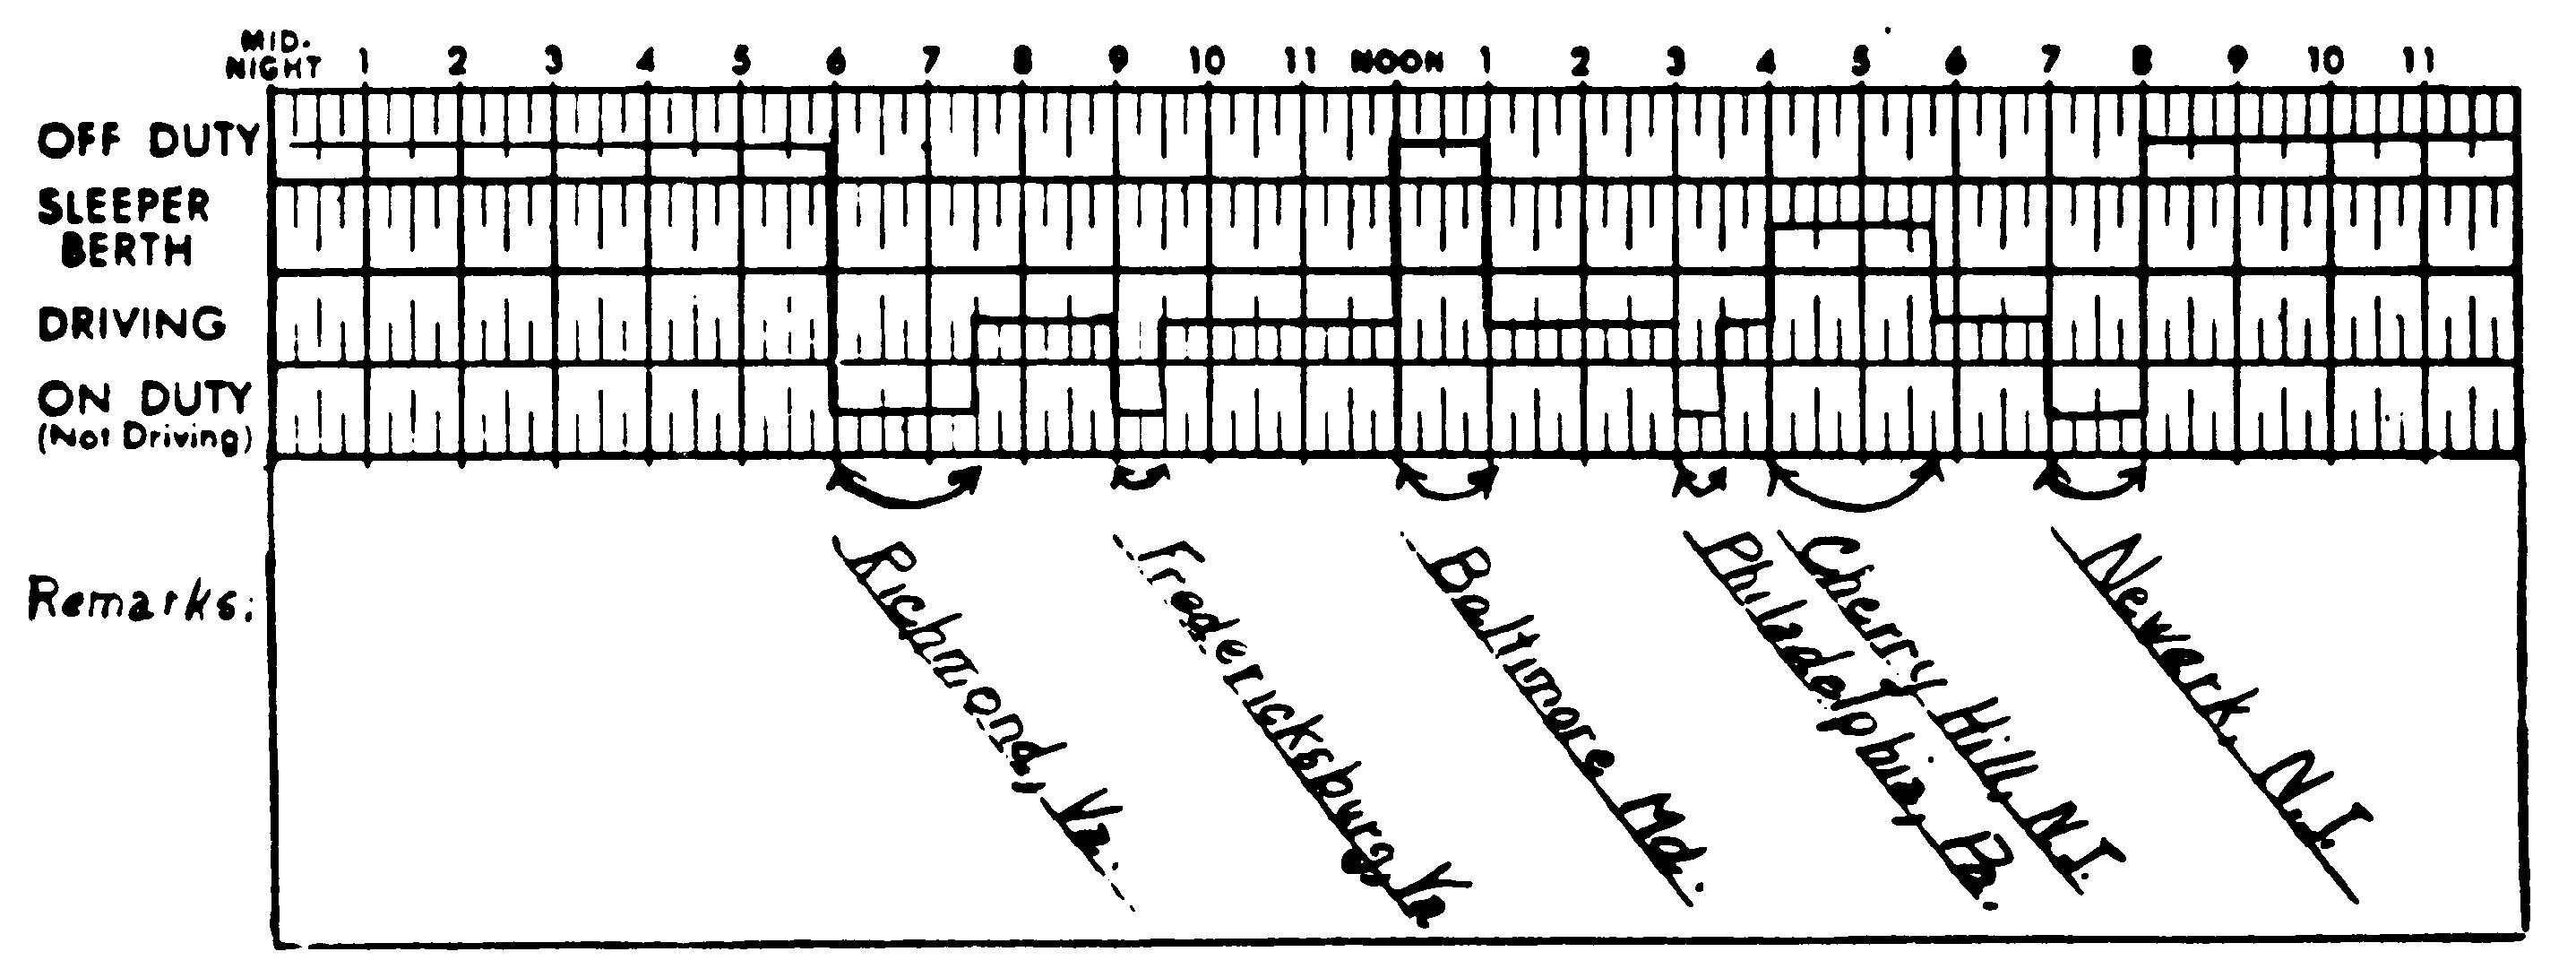


📌 Q2: What are the parking restrictions for vehicles carrying Division 1.1, 1.2, or 1.3 explosives?

Question: What are the parking restrictions for vehicles carrying Division 1.1, 1.2, or 1.3 explosives?

Grounded answer (extractive):
[TEXT | CFR-2024-title49-vol5-part397.pdf::page2 | score=0.600]
712  §397.5 parked in compliance with the laws, or- dinances, and regulations of the juris- diction in which it is being operated, unless they are at variance with spe- cific regulations of the Department of Transportation which are applicable to the operation of that vehicle and which impose a more

[TEXT | CFR-2024-title49-vol5-part397.pdf::page3 | score=0.339]
713  §397.9 [Reserved] §397.11 Fire...

📌 Q3: How should a driver record their duty status changes including sleeper berth time on the record of duty status?

Question: How should a driver record their duty status changes including sleeper berth time on the record of duty status?

Grounded answer (extractive):
[TEXT | CFR-2024-titl

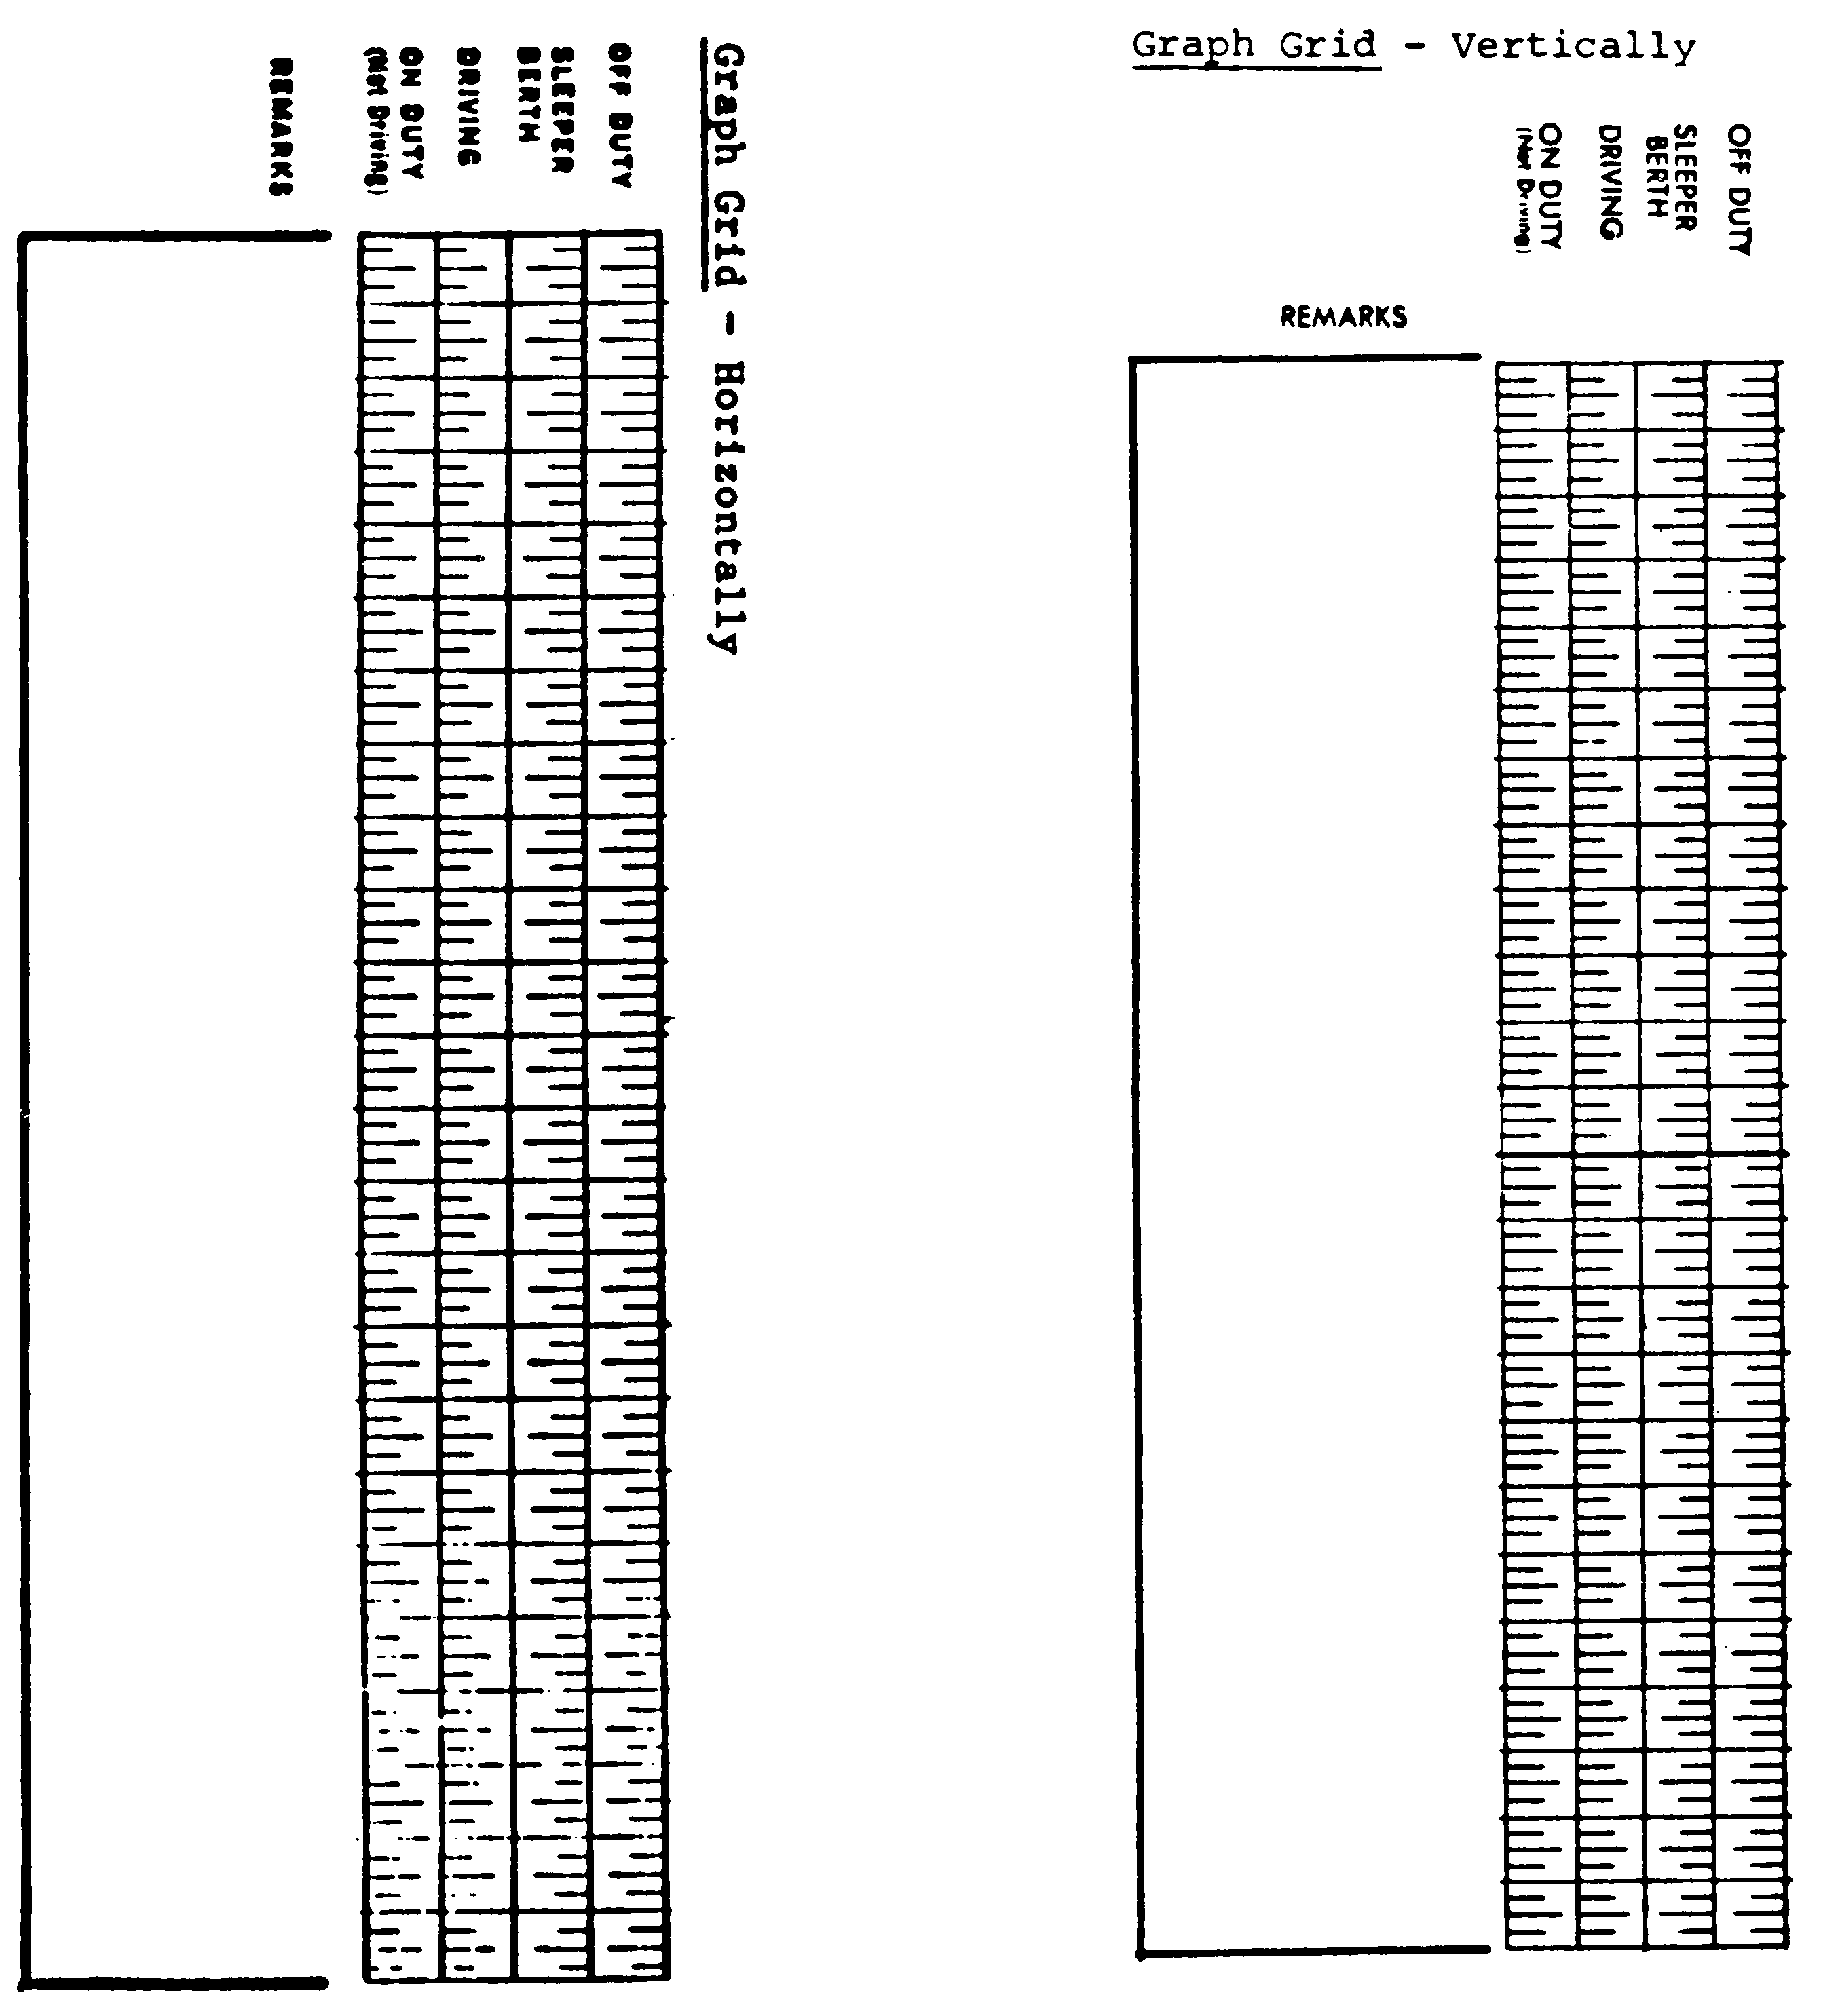

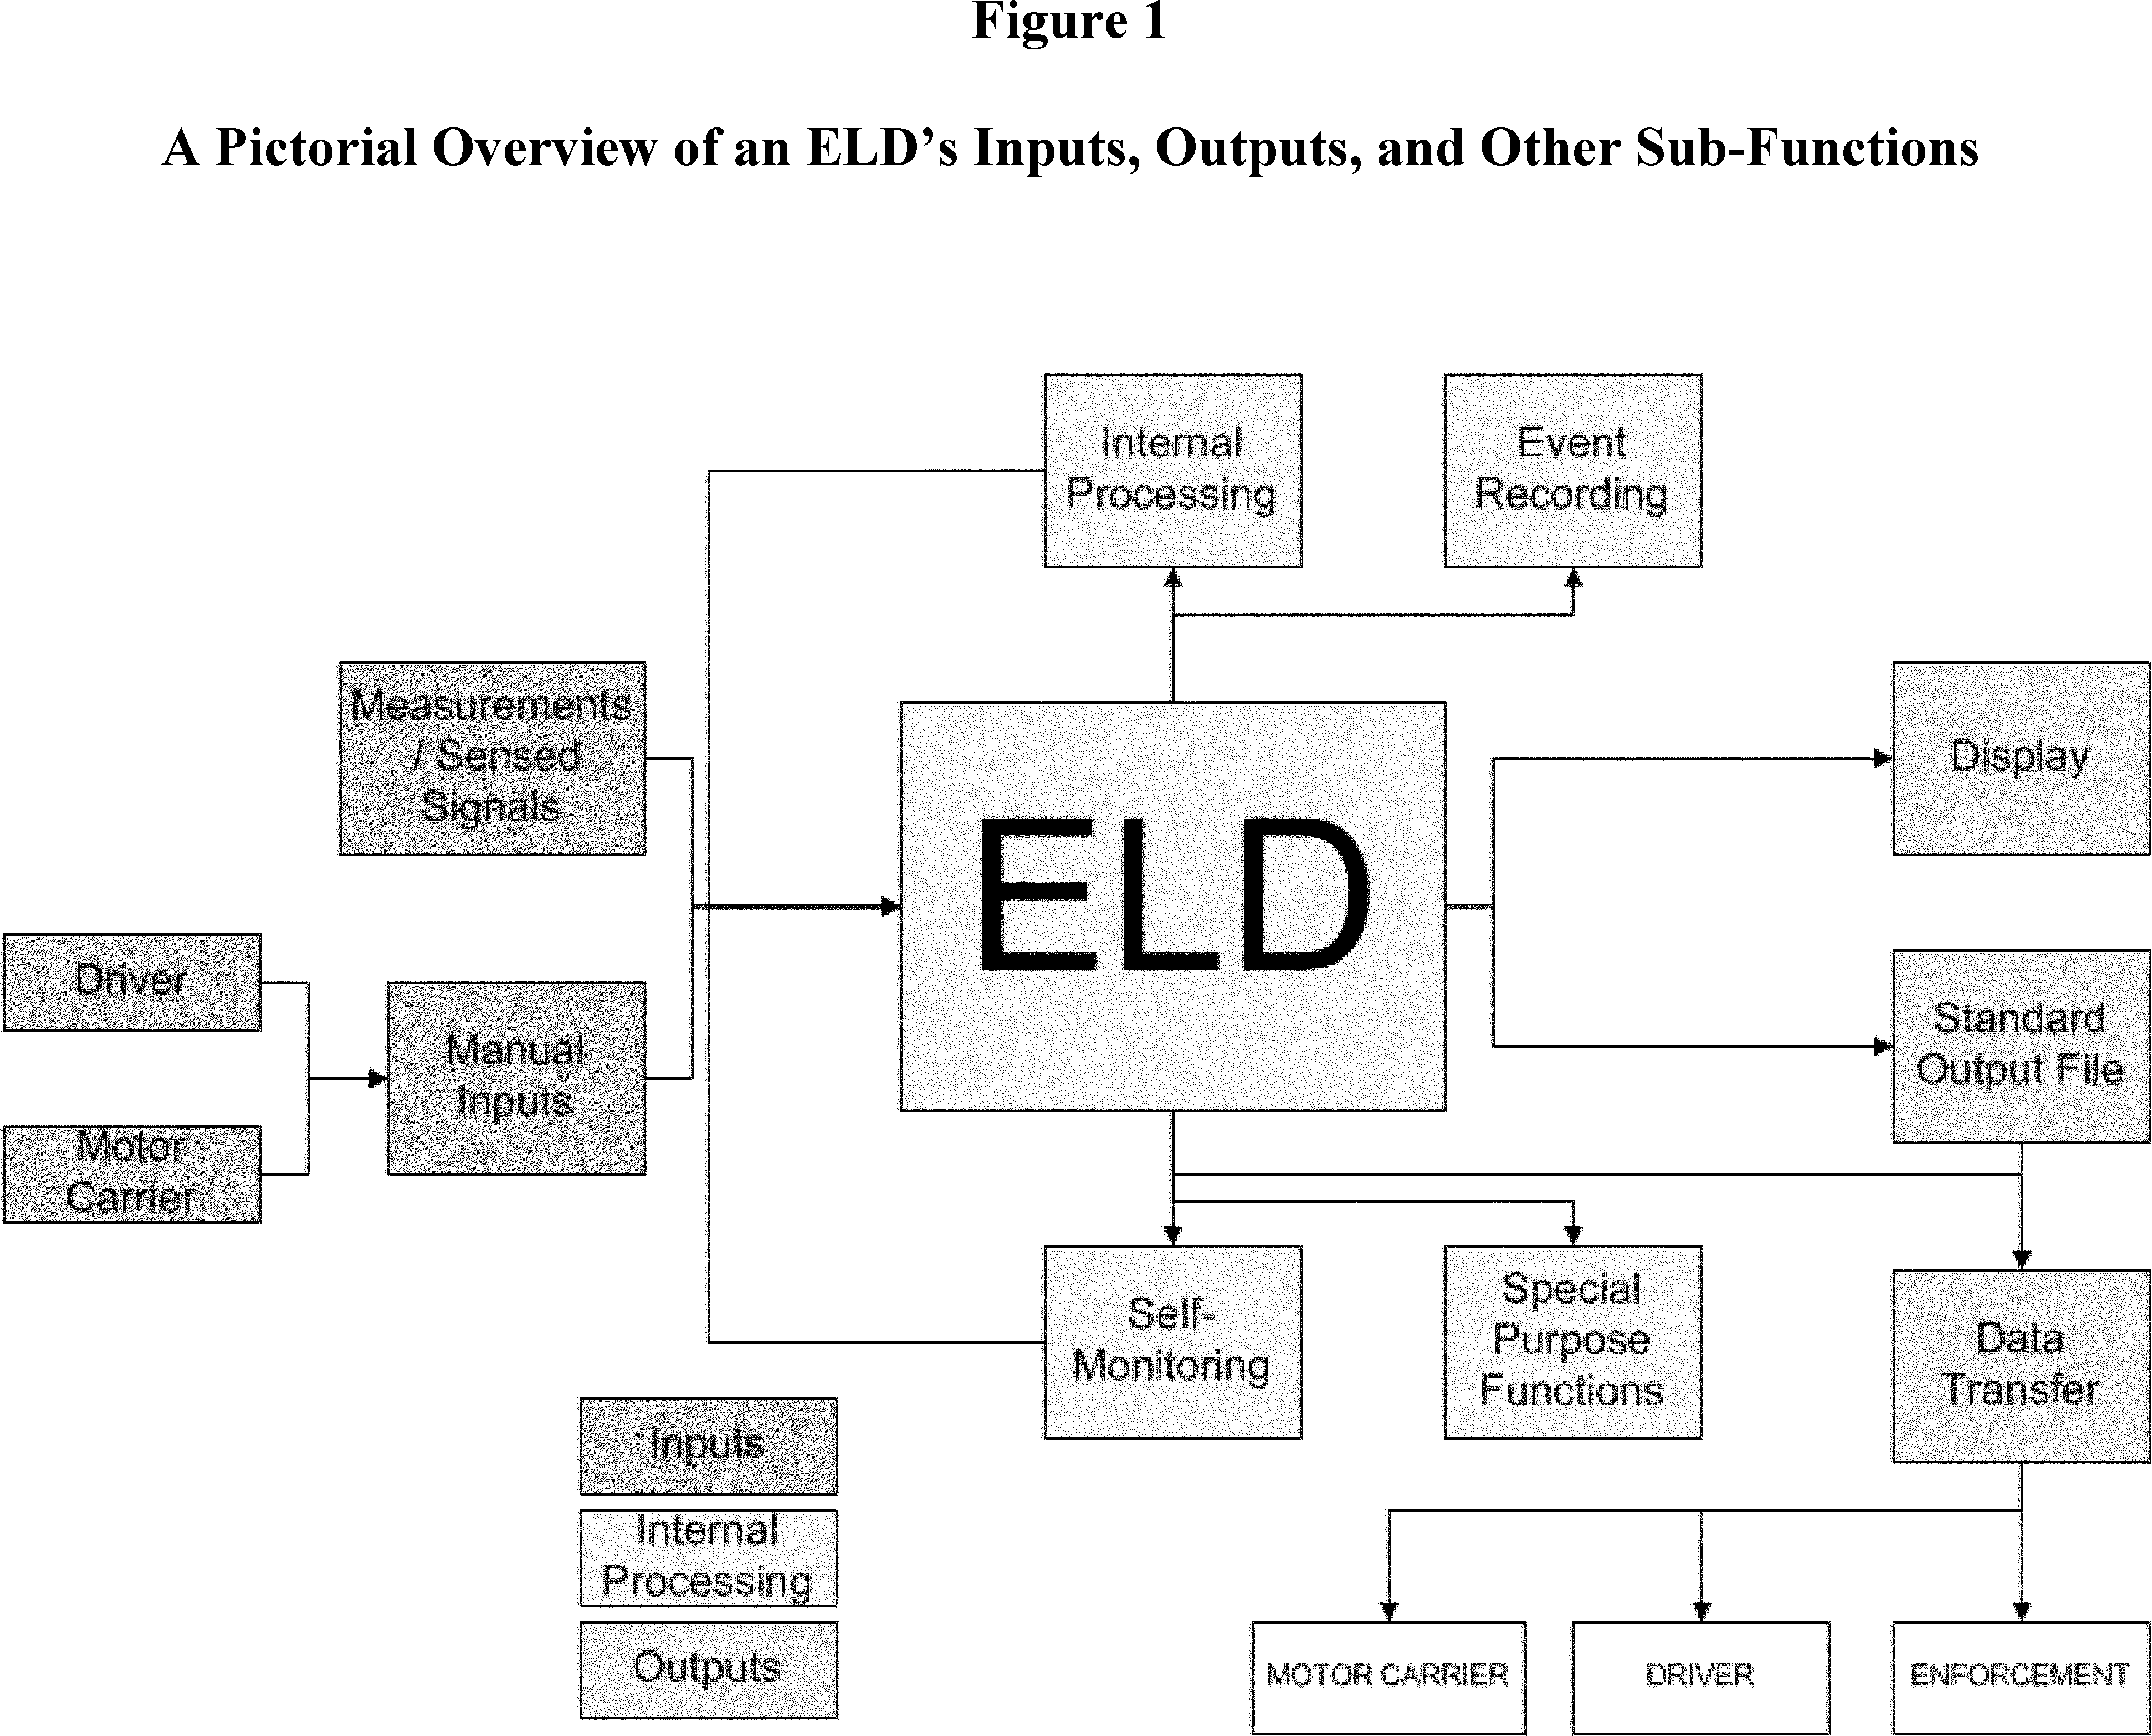

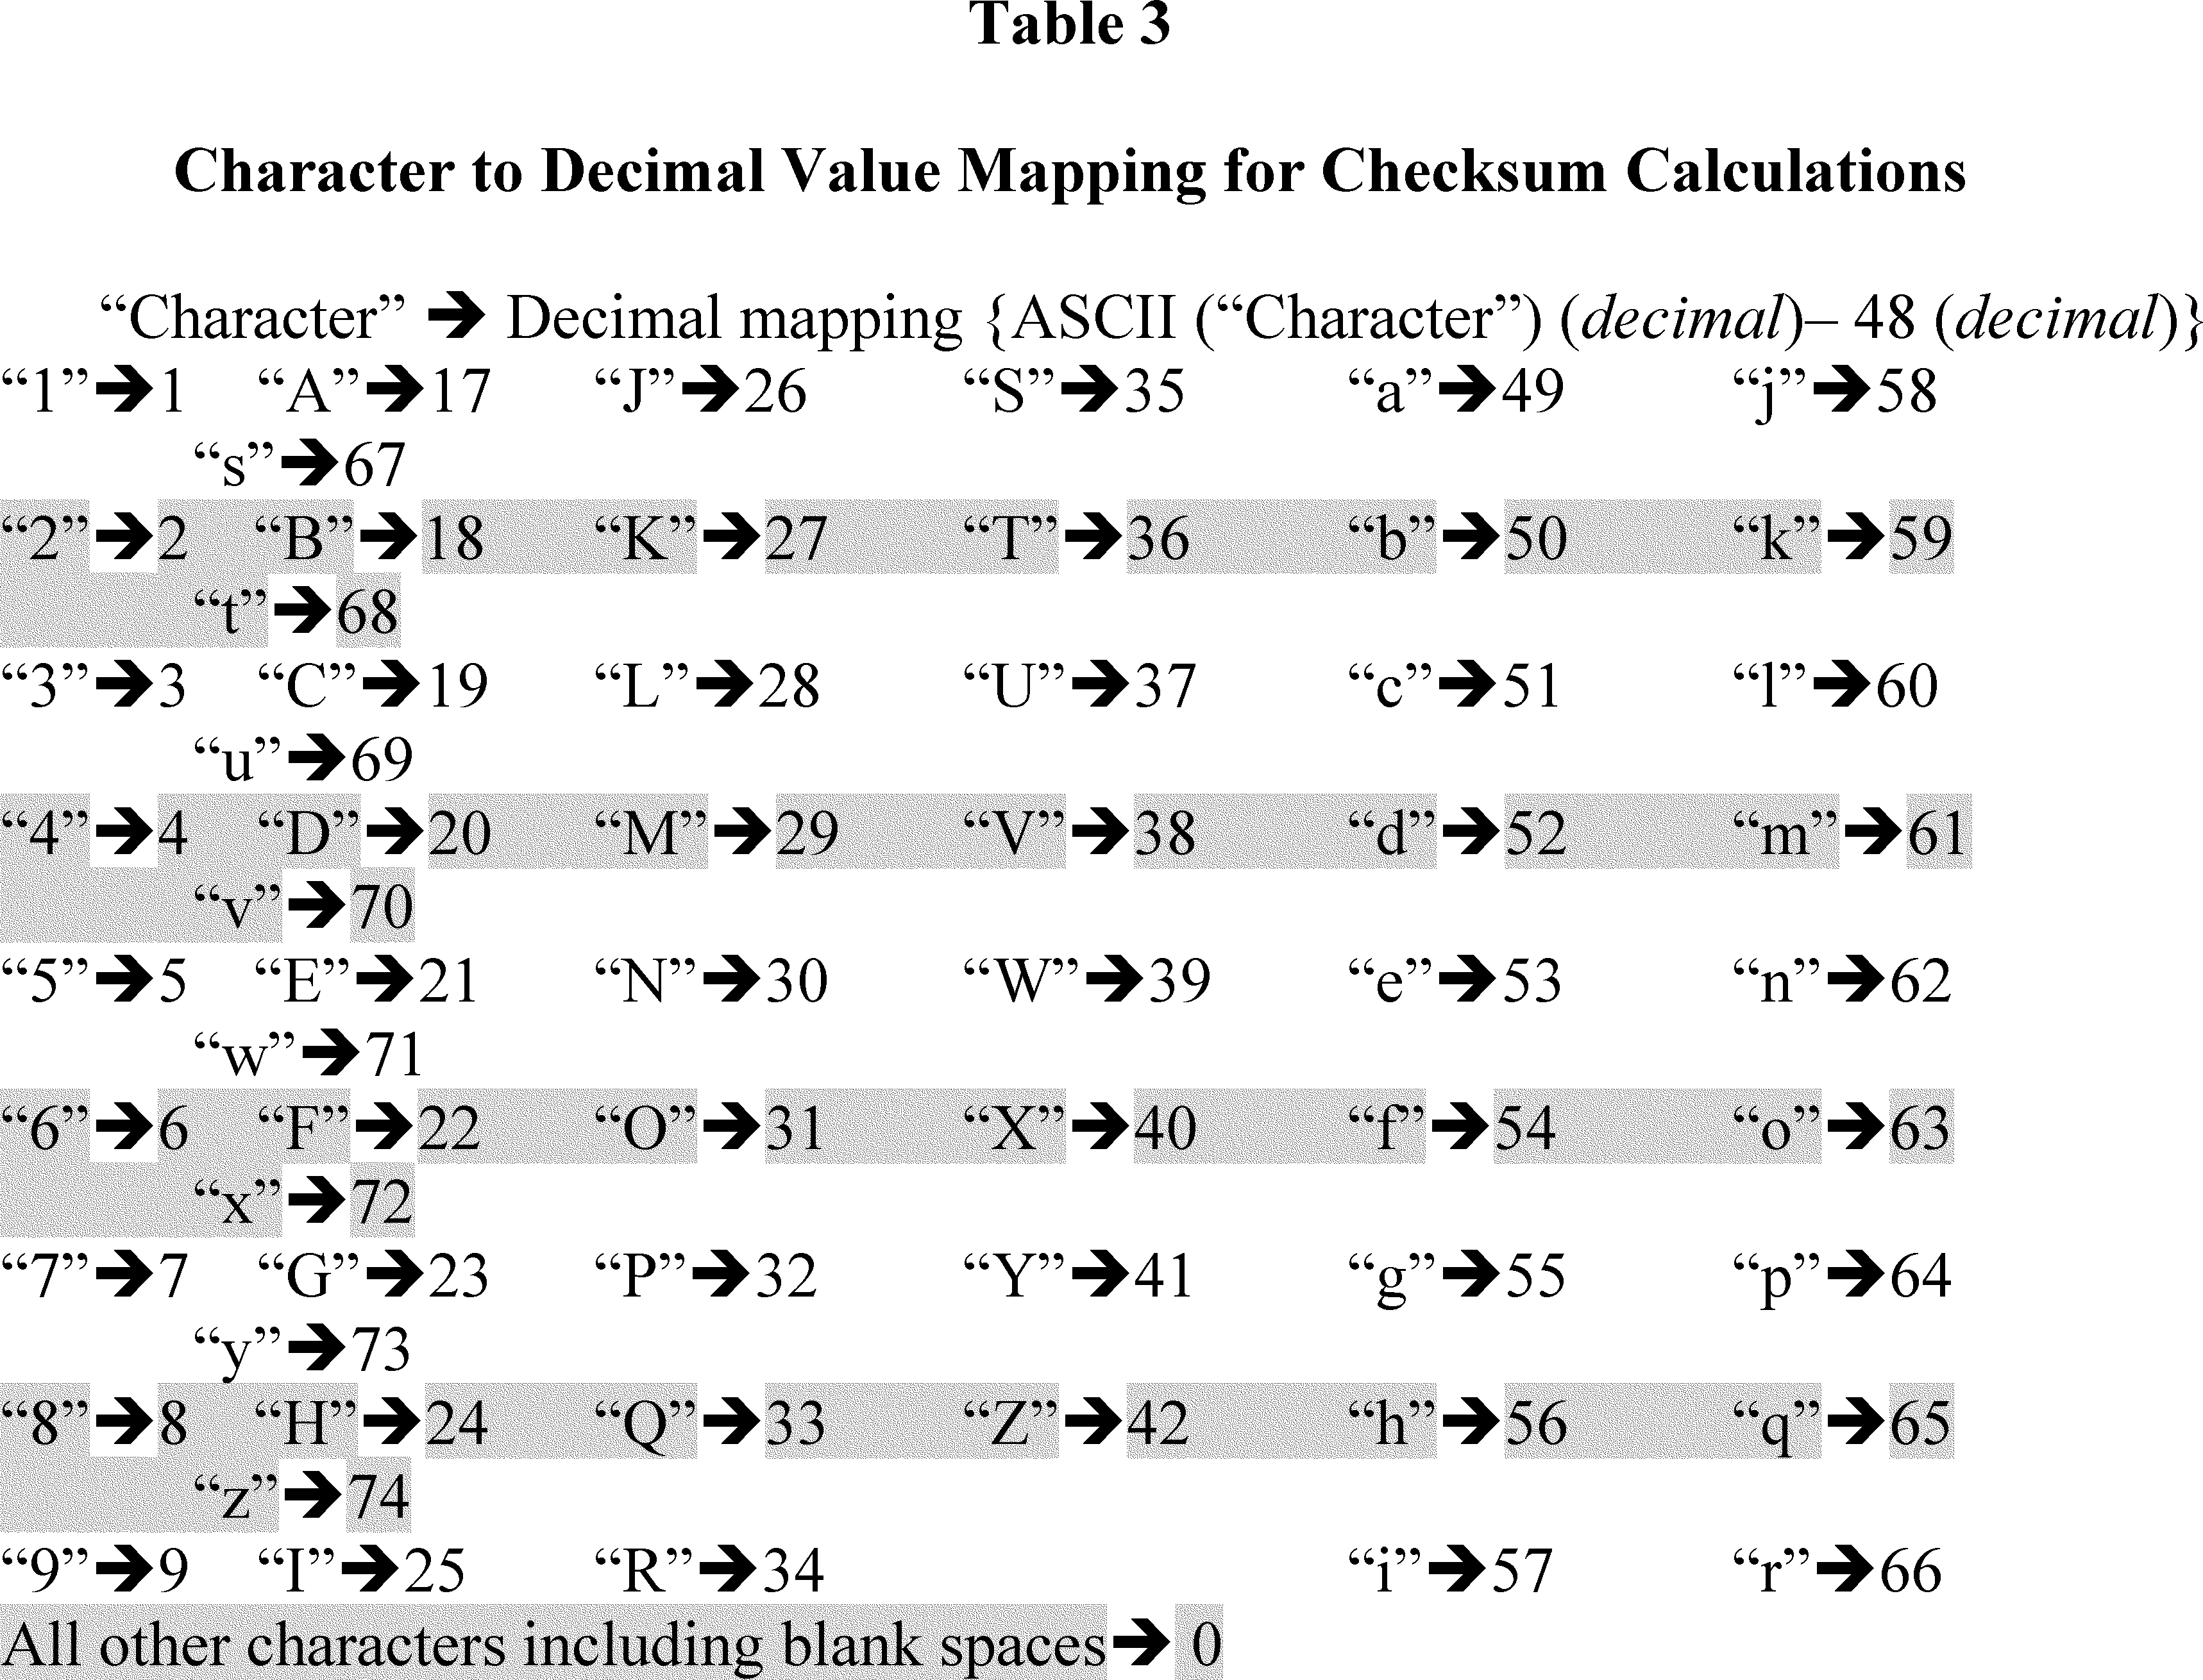

In [71]:
import google.generativeai as genai
from google.colab import userdata
from IPython.display import Image, display # Import for displaying images

# Configure Gemini API with your API key from Colab secrets
# You need to save your API key in Colab secrets under the name 'GOOGLE_API_KEY'
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

# Initialize the Gemini model (using a suitable model for text generation)
gemini_model = genai.GenerativeModel('gemini-2.5-flash')

def llm_answer_generator(question: str, context: str) -> str:
    """Generate an answer using a Large Language Model (LLM)."""
    prompt = f"""Given the following context, answer the question comprehensively and concisely.
    Ensure your answer is directly supported by the provided context. If the context does not contain enough information to answer the question, state that you cannot answer based on the provided information.

    Question: {question}

    Context:
    {context}

    Answer:"""

    try:
        response = gemini_model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"Error generating answer with LLM: {e}"

def simple_extractive_answer(question: str, context: str) -> str:
    """Extract answer from top evidence (no LLM required)."""
    lines = context.split("\n\n")
    if not lines:
        return "I don't know (no evidence retrieved)."

    return (
        f"Question: {question}\n\n"
        "Grounded answer (extractive):\n"
        + "\n\n".join(lines[:2])
    )

def run_query(qobj: Dict, method: str = "hybrid_rerank", use_llm: bool = False) -> Dict[str, Any]:
    """Run a single query through the RAG pipeline, with optional LLM generation."""
    question = qobj["question"]
    ctx = build_context(question, method=method)

    if use_llm:
        answer = llm_answer_generator(question, ctx["context"])
    else:
        answer = simple_extractive_answer(question, ctx["context"])

    return {
        "id": qobj["id"],
        "question": question,
        "method": method,
        "answer": answer,
        "context": ctx["context"],
        "image_paths": ctx["image_paths"],
        "evidence": ctx["evidence"],
    }

# Run all queries with the LLM generator
# If you don't want to use the LLM, set `skip_llm=True`.
# NOTE: You must have GOOGLE_API_KEY set in Colab secrets for this to work.
skip_llm = True

if not skip_llm:
  print("🚀 Running queries with hybrid+rerank method and LLM generator:\n")

  results_with_llm = [run_query(q, method="hybrid_rerank", use_llm=True) for q in QUERIES]

  for r in results_with_llm:
      print("=" * 80)
      print(f"📌 {r['id']}: {r['question']}")
      print(f"\n{r['answer'][:600]}...")
      if r['image_paths']:
          print(f"\n🖼️  Relevant images:")
          for img_path in r['image_paths']:
              display(Image(filename=img_path, width=200)) # Display images
      print()

print("\n🚀 Running queries with hybrid+rerank method and simple extractive generator (for comparison):\n")
results_extractive = [run_query(q, method="hybrid_rerank", use_llm=False) for q in QUERIES]

for r in results_extractive:
    print("=" * 80)
    print(f"📌 {r['id']}: {r['question']}")
    print(f"\n{r['answer'][:600]}...")
    if r['image_paths']:
        print(f"\n🖼️  Relevant images:")
        for img_path in r['image_paths']:
            display(Image(filename=img_path, width=200)) # Display images
    print()


## 8) Retrieval Evaluation (Precision@k / Recall@k)
We treat a text chunk as **relevant** for a query if it contains at least one `must_have_keywords` term.



In [72]:
def is_relevant_text(chunk_text: str, rubric: Dict) -> bool:
    """Check if chunk is relevant based on keyword matching."""
    text = chunk_text.lower()
    must_have = [k.lower() for k in rubric.get("must_have_keywords", [])]
    return any(kw in text for kw in must_have)

def precision_at_k(relevances: List[bool], k: int) -> float:
    """Precision@k: fraction of top-k that are relevant."""
    k = min(k, len(relevances))
    if k == 0:
        return 0.0
    return sum(relevances[:k]) / k

def recall_at_k(relevances: List[bool], k: int, total_relevant: int) -> float:
    """Recall@k: fraction of all relevant items retrieved in top-k."""
    k = min(k, len(relevances))
    if total_relevant == 0:
        return 0.0
    return sum(relevances[:k]) / total_relevant

def evaluate_retrieval(
    qobj: Dict,
    method: str,
    chunks: List[TextChunk],
    top_k: int = 10
) -> Dict[str, Any]:
    """Evaluate retrieval for a single query."""
    question = qobj["question"]
    rubric = qobj["rubric"]

    # Get retrieval results
    ctx = build_context(question, method=method, chunks=chunks, top_k_text=top_k)

    # Check relevance for each text result
    relevances = []
    for ev in ctx["evidence"]:
        if ev["modality"] == "text":
            relevances.append(is_relevant_text(ev["text"], rubric))

    # Calculate total relevant in corpus
    total_relevant = sum(is_relevant_text(c.text, rubric) for c in chunks)

    return {
        "query_id": qobj["id"],
        "method": method,
        "chunk_type": chunks[0].chunk_type if chunks else "unknown",
        "P@5": precision_at_k(relevances, 5),
        "R@10": recall_at_k(relevances, 10, total_relevant),
        "total_relevant": total_relevant,
        "retrieved_relevant": sum(relevances),
    }

# Quick evaluation demo
print("📊 Quick evaluation for Q1 with different methods:\n")
for method in ["sparse", "dense", "hybrid", "hybrid_rerank"]:
    result = evaluate_retrieval(QUERIES[0], method, page_chunks)
    print(f"   {method:15} | P@5={result['P@5']:.3f} | R@10={result['R@10']:.3f}")


📊 Quick evaluation for Q1 with different methods:

   sparse          | P@5=1.000 | R@10=0.194
   dense           | P@5=1.000 | R@10=0.161
   hybrid          | P@5=1.000 | R@10=0.194
   hybrid_rerank   | P@5=1.000 | R@10=0.194


## 9) Ablation Study (REQUIRED)

You must compare **at least**:
- **Chunking A (page-based)** vs **Chunking B (fixed-size)**  
- **Sparse** vs **Dense** vs **Hybrid** vs **Hybrid + Rerank** *(dense/rerank can be optional extensions — but include at least sparse + one fusion variant)*  
- **Text-only RAG** vs **Multimodal RAG** (your context must include evidence items)

**Deliverable:** include a final results table in your README:

`Query × Method × Precision@5 × Recall@10 × Faithfulness`

### Quick ablation ideas
- Vary `TOP_K_TEXT`: 2, 5, 10  
- Vary `ALPHA`: 0.2, 0.5, 0.8  
- Compare page-chunking vs fixed-size (`CHUNK_SIZE` / `CHUNK_OVERLAP`)  


In [73]:
print("🔬 Running comprehensive ablation study...")
print("   This evaluates all combinations of:")
print("   - Chunking: page-based, fixed-size")
print("   - Methods: sparse, dense, hybrid, hybrid_rerank")
print("   - Queries: Q1, Q2, Q3")
print()

ablation_results = []

# Define configurations
chunk_configs = [
    ("page", page_chunks),
    ("fixed", fixed_chunks),
]

methods = ["sparse", "dense", "hybrid", "hybrid_rerank"]

# Run all combinations
for chunk_name, chunks in chunk_configs:
    for method in methods:
        for qobj in QUERIES:
            try:
                result = evaluate_retrieval(qobj, method, chunks)
                result["chunk_type"] = chunk_name
                ablation_results.append(result)
            except Exception as e:
                print(f"   ⚠️  Error with {chunk_name}/{method}/{qobj['id']}: {e}")

# Create results DataFrame
df_ablation = pd.DataFrame(ablation_results)

# Pivot for nice display
print("\n📊 ABLATION RESULTS TABLE")
print("=" * 80)

# Group by method and chunk type, average across queries
summary = df_ablation.groupby(["chunk_type", "method"]).agg({
    "P@5": "mean",
    "R@10": "mean",
}).round(3)

print(summary)

# Full detailed table
print("\n\n📋 DETAILED RESULTS (per query)")
print("=" * 80)
display_cols = ["query_id", "chunk_type", "method", "P@5", "R@10", "total_relevant"]
print(df_ablation[display_cols].to_string(index=False))

🔬 Running comprehensive ablation study...
   This evaluates all combinations of:
   - Chunking: page-based, fixed-size
   - Methods: sparse, dense, hybrid, hybrid_rerank
   - Queries: Q1, Q2, Q3


📊 ABLATION RESULTS TABLE
                            P@5   R@10
chunk_type method                     
fixed      dense          0.533  0.016
           hybrid         0.533  0.020
           hybrid_rerank  0.533  0.021
           sparse         0.867  0.069
page       dense          0.867  0.163
           hybrid         0.933  0.202
           hybrid_rerank  0.933  0.202
           sparse         0.867  0.187


📋 DETAILED RESULTS (per query)
query_id chunk_type        method  P@5     R@10  total_relevant
      Q1       page        sparse  1.0 0.193548              31
      Q2       page        sparse  0.6 0.250000              12
      Q3       page        sparse  1.0 0.117647              51
      Q1       page         dense  1.0 0.161290              31
      Q2       page         dense  

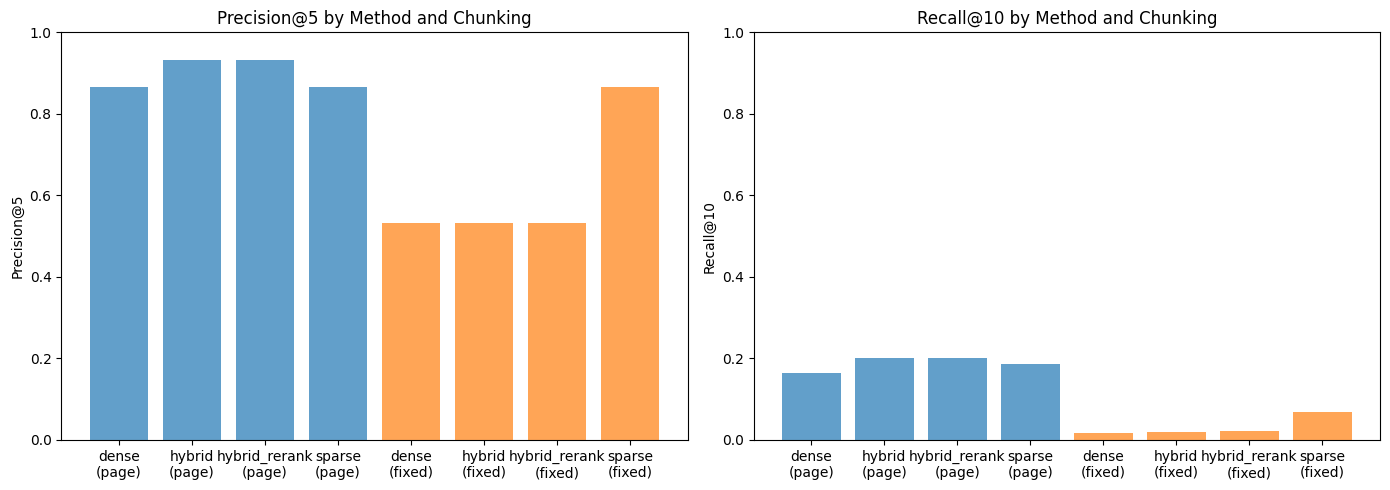

📈 Ablation visualization saved to 'ablation_results.png'


In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: P@5 by method
ax1 = axes[0]
for chunk_type in ["page", "fixed"]:
    data = df_ablation[df_ablation["chunk_type"] == chunk_type]
    means = data.groupby("method")["P@5"].mean()
    ax1.bar([f"{m}\n({chunk_type})" for m in means.index], means.values, alpha=0.7)
ax1.set_ylabel("Precision@5")
ax1.set_title("Precision@5 by Method and Chunking")
ax1.set_ylim(0, 1)

# Plot 2: R@10 by method
ax2 = axes[1]
for chunk_type in ["page", "fixed"]:
    data = df_ablation[df_ablation["chunk_type"] == chunk_type]
    means = data.groupby("method")["R@10"].mean()
    ax2.bar([f"{m}\n({chunk_type})" for m in means.index], means.values, alpha=0.7)
ax2.set_ylabel("Recall@10")
ax2.set_title("Recall@10 by Method and Chunking")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("ablation_results.png", dpi=150)
plt.show()

print("📈 Ablation visualization saved to 'ablation_results.png'")

## 10) Faithfulness Assessment

For each query, manually assess whether the retrieved evidence supports the answer.

In [64]:
def assess_faithfulness(qobj: Dict, evidence: List[Dict]) -> Dict[str, Any]:
    """
    Assess faithfulness: does the evidence support answering the question?

    Scoring:
    - 2: Strong support - evidence directly answers the question
    - 1: Partial support - evidence is relevant but incomplete
    - 0: No support - evidence doesn't help answer the question
    """
    rubric = qobj["rubric"]
    must_have = [k.lower() for k in rubric.get("must_have_keywords", [])]

    # Count how many must-have keywords appear in evidence
    evidence_text = " ".join([e["text"].lower() for e in evidence if e["modality"] == "text"])
    keywords_found = sum(1 for kw in must_have if kw in evidence_text)
    keyword_coverage = keywords_found / len(must_have) if must_have else 0

    # Score based on coverage
    if keyword_coverage >= 0.6:
        score = 2
        assessment = "Strong support"
    elif keyword_coverage >= 0.3:
        score = 1
        assessment = "Partial support"
    else:
        score = 0
        assessment = "Insufficient support"

    return {
        "query_id": qobj["id"],
        "faithfulness_score": score,
        "assessment": assessment,
        "keyword_coverage": keyword_coverage,
        "keywords_found": keywords_found,
        "keywords_total": len(must_have),
    }

# Assess faithfulness for best method
print("📝 FAITHFULNESS ASSESSMENT (using hybrid_rerank method)")
print("=" * 80)

faithfulness_results = []
for qobj in QUERIES:
    ctx = build_context(qobj["question"], method="hybrid_rerank")
    faith = assess_faithfulness(qobj, ctx["evidence"])
    faithfulness_results.append(faith)

    print(f"\n{qobj['id']}: {qobj['question'][:60]}...")
    print(f"   Score: {faith['faithfulness_score']}/2 ({faith['assessment']})")
    print(f"   Keywords: {faith['keywords_found']}/{faith['keywords_total']} found ({faith['keyword_coverage']:.1%})")

df_faith = pd.DataFrame(faithfulness_results)

📝 FAITHFULNESS ASSESSMENT (using hybrid_rerank method)

Q1: What are the maximum driving hours allowed for a property-ca...
   Score: 2/2 (Strong support)
   Keywords: 6/6 found (100.0%)

Q2: What are the parking restrictions for vehicles carrying Divi...
   Score: 2/2 (Strong support)
   Keywords: 8/10 found (80.0%)

Q3: How should a driver record their duty status changes includi...
   Score: 2/2 (Strong support)
   Keywords: 8/8 found (100.0%)


## 11) Final Results Summary

Combine all results into the required output format.

In [65]:
print("\n" + "=" * 80)
print("📊 FINAL RESULTS TABLE")
print("Query × Method × Precision@5 × Recall@10 × Faithfulness")
print("=" * 80)

# Best method results with faithfulness
final_results = []
for qobj in QUERIES:
    for method in ["sparse", "hybrid_rerank"]:  # Show baseline vs best
        eval_result = evaluate_retrieval(qobj, method, page_chunks)
        ctx = build_context(qobj["question"], method=method)
        faith = assess_faithfulness(qobj, ctx["evidence"])

        final_results.append({
            "Query": qobj["id"],
            "Method": method,
            "P@5": f"{eval_result['P@5']:.3f}",
            "R@10": f"{eval_result['R@10']:.3f}",
            "Faithfulness": f"{faith['faithfulness_score']}/2",
        })

df_final = pd.DataFrame(final_results)
print(df_final.to_string(index=False))


📊 FINAL RESULTS TABLE
Query × Method × Precision@5 × Recall@10 × Faithfulness
Query        Method   P@5  R@10 Faithfulness
   Q1        sparse 1.000 0.194          2/2
   Q1 hybrid_rerank 1.000 0.194          2/2
   Q2        sparse 0.600 0.250          2/2
   Q2 hybrid_rerank 0.800 0.333          2/2
   Q3        sparse 1.000 0.118          2/2
   Q3 hybrid_rerank 1.000 0.078          2/2


## 12) Key Findings & Discussion

**Write your analysis here:**

### Chunking Strategy
- Page-based chunking seemed to perform better than fixed-length chunking. I suspect this is due to fixed-length chunks being too fragmented.

### Retrieval Methods
- Sparse (TF-IDF) performance: brought better context to the model
- Dense embeddings performance: had trouble getting good context
- Hybrid fusion: certainly helped with page-based chunking, but didn't really help with fixed-length chunking
- Reranking: neither hurt nor helped results, so might not be worth doing

### Multimodal Evidence
- Query 3 returned the exact image required, showing an example of how drivers should record their duty status.

### Query Failure
- Query 1 seemed to miss the point of the question, even after toying with the question to get a better answer. It generates some tangentially relevant information, but claims it can't find an answer to the question. However, the relevant documents directly answer the question.

## 13) What to submit
1) Your updated dataset (or keep your own)
2) This notebook (with your answers + screenshots/outputs)
3) A short write‑up: retrieval metrics + faithfulness discussion + ablation

**Tip:** If you switch to an LLM, keep the same `build_context()` so the evidence is always visible.


In [66]:
df_ablation.to_csv("ablation_results.csv", index=False)
df_final.to_csv("final_results.csv", index=False)
print("💾 Results saved to CSV files")

💾 Results saved to CSV files
